# Jump Plus AM-FM Mode Decomposition (JMD / MJMD)

This notebook introduces **Jump Plus AM-FM Mode Decomposition (JMD)** and its multivariate extension **MJMD**, with executable PySDKit examples.

Both methods jointly extract:

- narrow-band **AM–FM oscillatory modes** (VMD / MVMD style), and
- a discontinuous **jump** component (JOT-style ADMM prior).

**Reference**

> M. Nazari, A. R. Korshøj, N. ur Rehman.  
> *Jump Plus AM-FM Mode Decomposition.*  
> IEEE Transactions on Signal Processing (arXiv:2407.07800).  
> [https://doi.org/10.48550/arXiv.2407.07800](https://doi.org/10.48550/arXiv.2407.07800)

## 1. Motivation

Classical EMD / VMD focus on oscillatory IMFs. Abrupt discontinuities (jumps) have a **wide-band** spectrum and often pollute every mode.

Jump-extraction methods (e.g. JOT) recover discontinuities / trends, but typically treat all oscillations as a single residual.

**JMD / MJMD** solve one variational problem that accounts for both behaviors at once.

## 2. Core idea (univariate JMD)

A signal is modeled as

$$
x(t)=\sum_{k=1}^{K}u_k(t)+v(t),
$$

where $u_k$ are band-limited AM–FM modes and $v$ is a piecewise-smooth jump.

### Oscillatory part (VMD-like)

Modes are updated in the frequency domain by a Wiener filter of the residual
$\hat x - \sum_{i\ne k}\hat u_i - \hat v$, with a scheduled bandwidth weight $\alpha\,\phi_n$.

### Jump part (ADMM)

The jump uses a difference operator $D$ and a non-convex sparse prior on $Dv$, solved by ADMM updates of $(v,x,\rho)$ with parameters $(\beta,\bar b,\tau)$.

### Multivariate MJMD

For $C$ channels, modes share **common center frequencies** $\omega_k$ (as in MVMD), while each channel keeps its own jump $v_c(t)$.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().resolve()
if (ROOT / "pysdkit").is_dir() and str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
elif (ROOT.parent / "pysdkit").is_dir() and str(ROOT.parent) not in sys.path:
    sys.path.insert(0, str(ROOT.parent))

from pysdkit import JMD, MJMD
from pysdkit.plot import plot_IMFs, plot_signal

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.figsize"] = (9, 3.2)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(JMD(K=2))
print(MJMD(K=2))

Jump Plus AM-FM Mode Decomposition (JMD)
Multivariate Jump Plus AM-FM Mode Decomposition (MJMD)


## 3. Univariate demo (JMD)

Two tones + a step jump + light noise (shortened form of the MATLAB `JMD_test.m` idea).

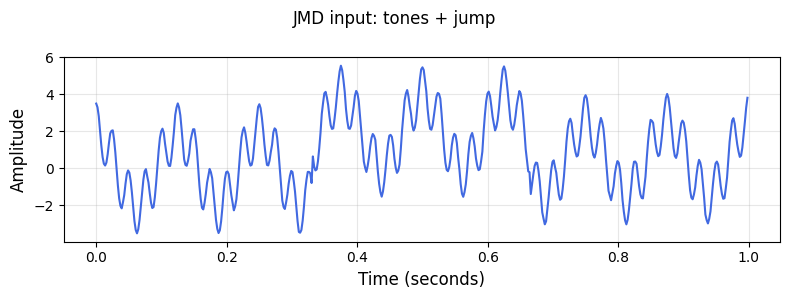

modes: (2, 512) jump: (512,)
center frequencies (normalized): [0.0156 0.0781]
Hz (if fs=N): [ 8.0002 39.9996]
reconstruction RE: 0.023413259642113264


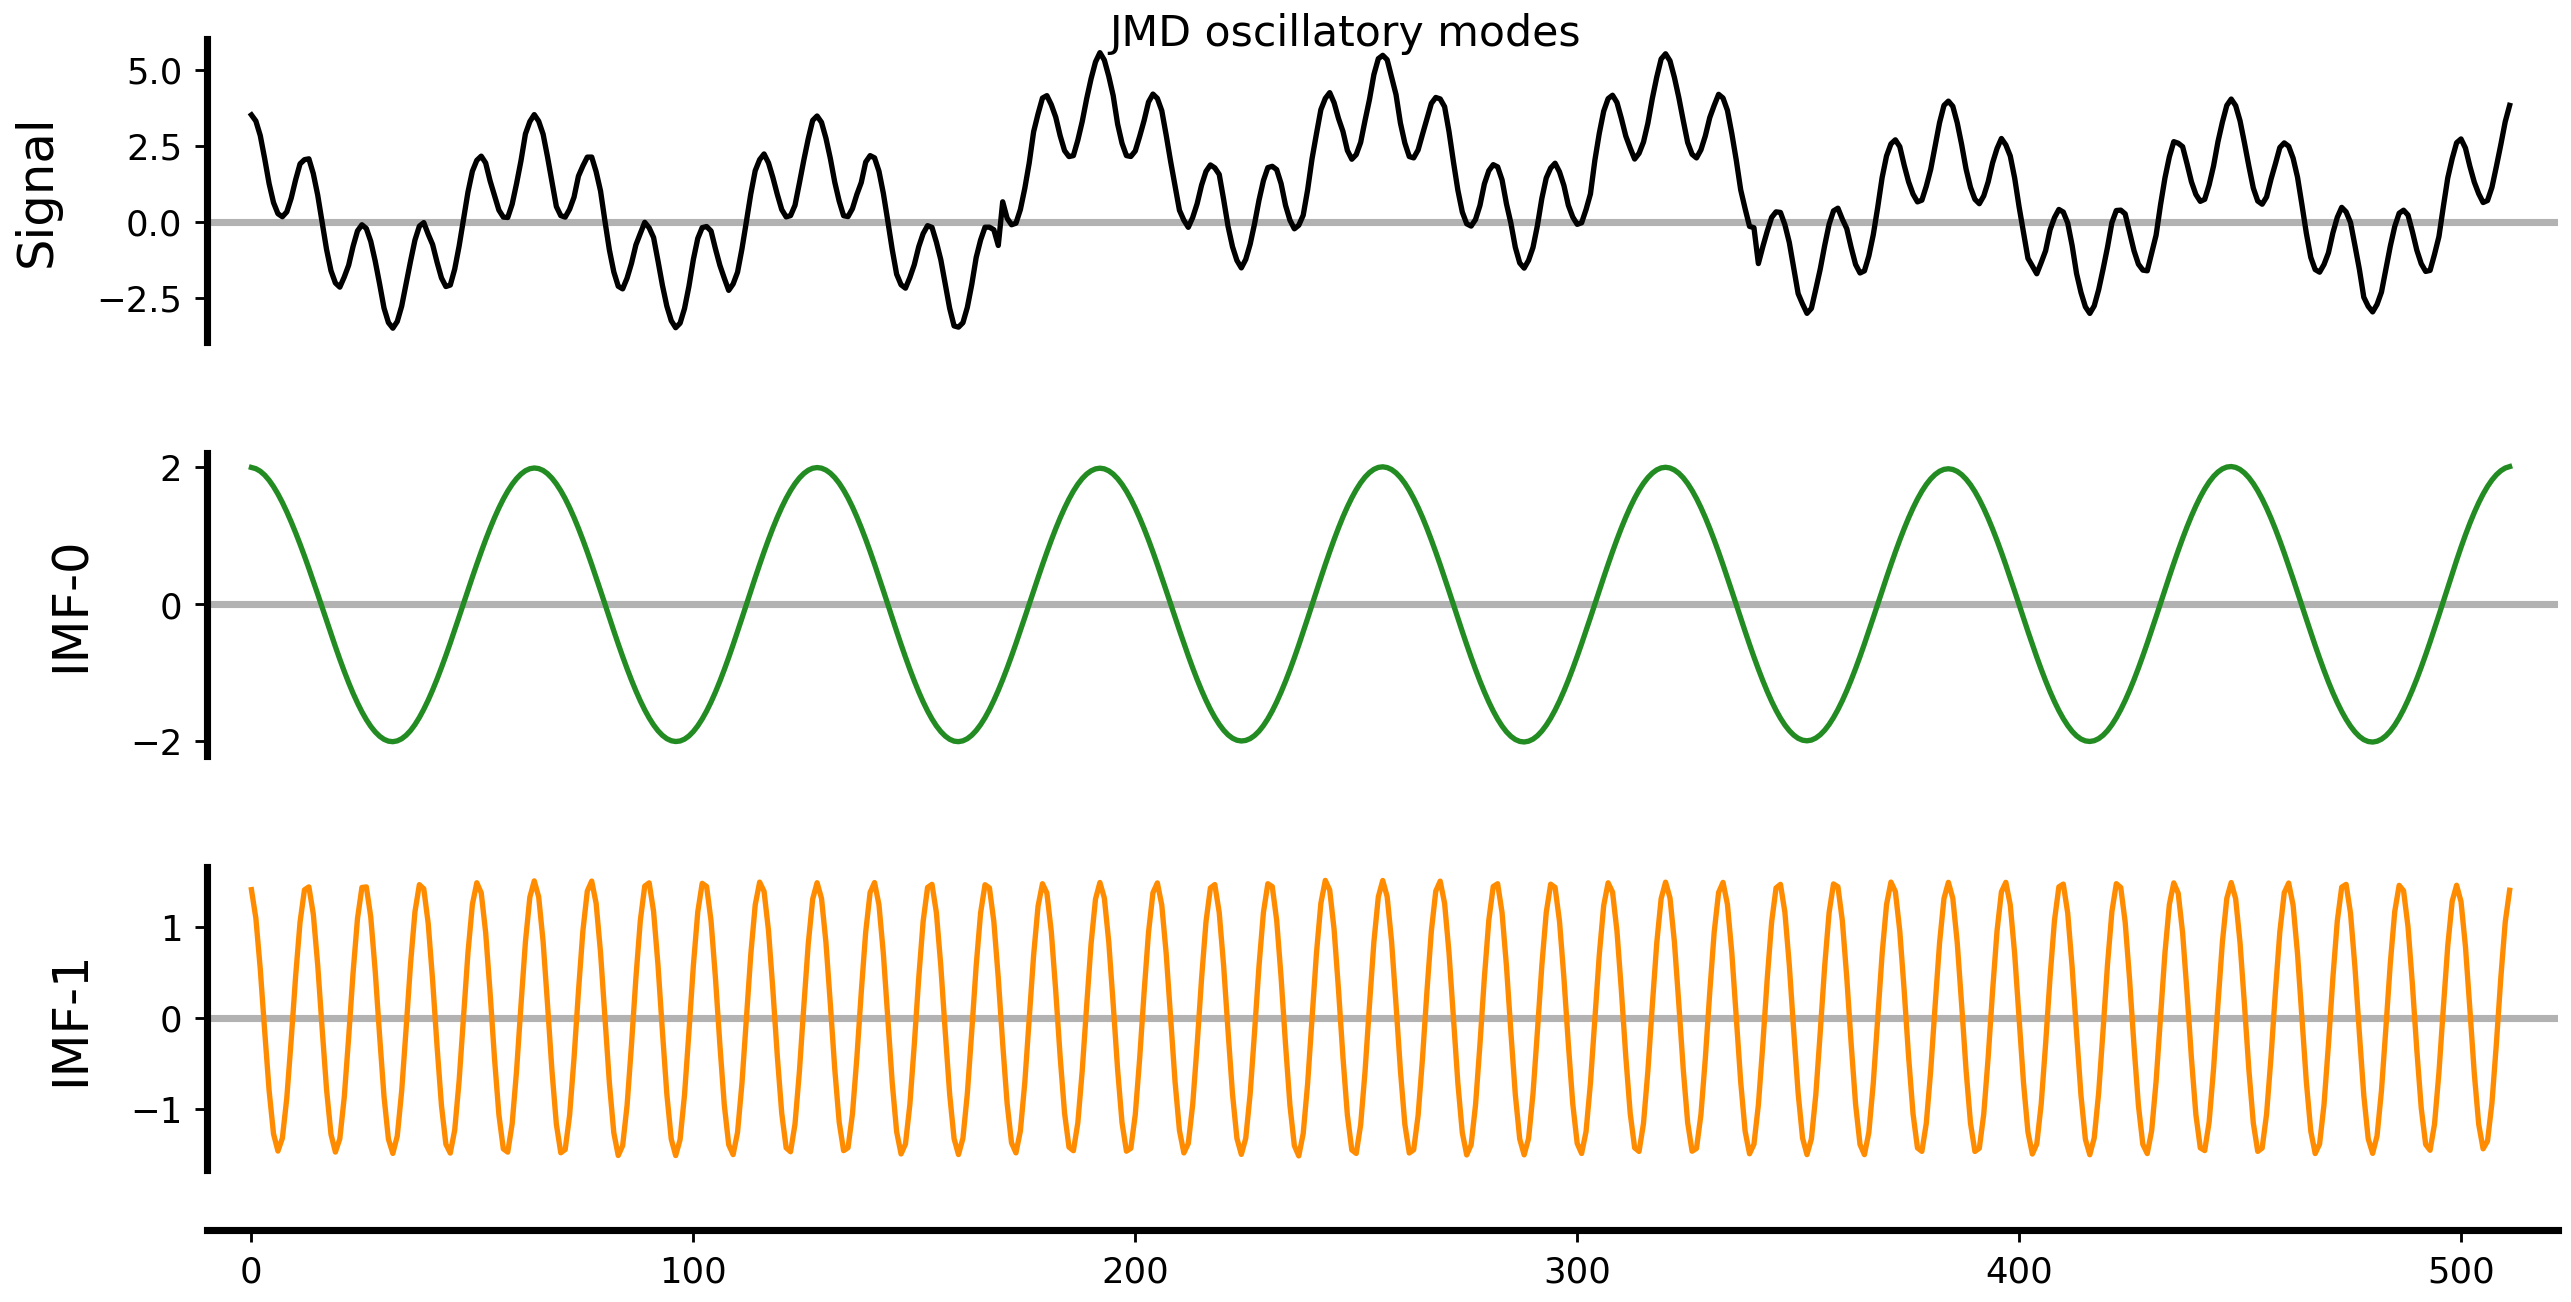

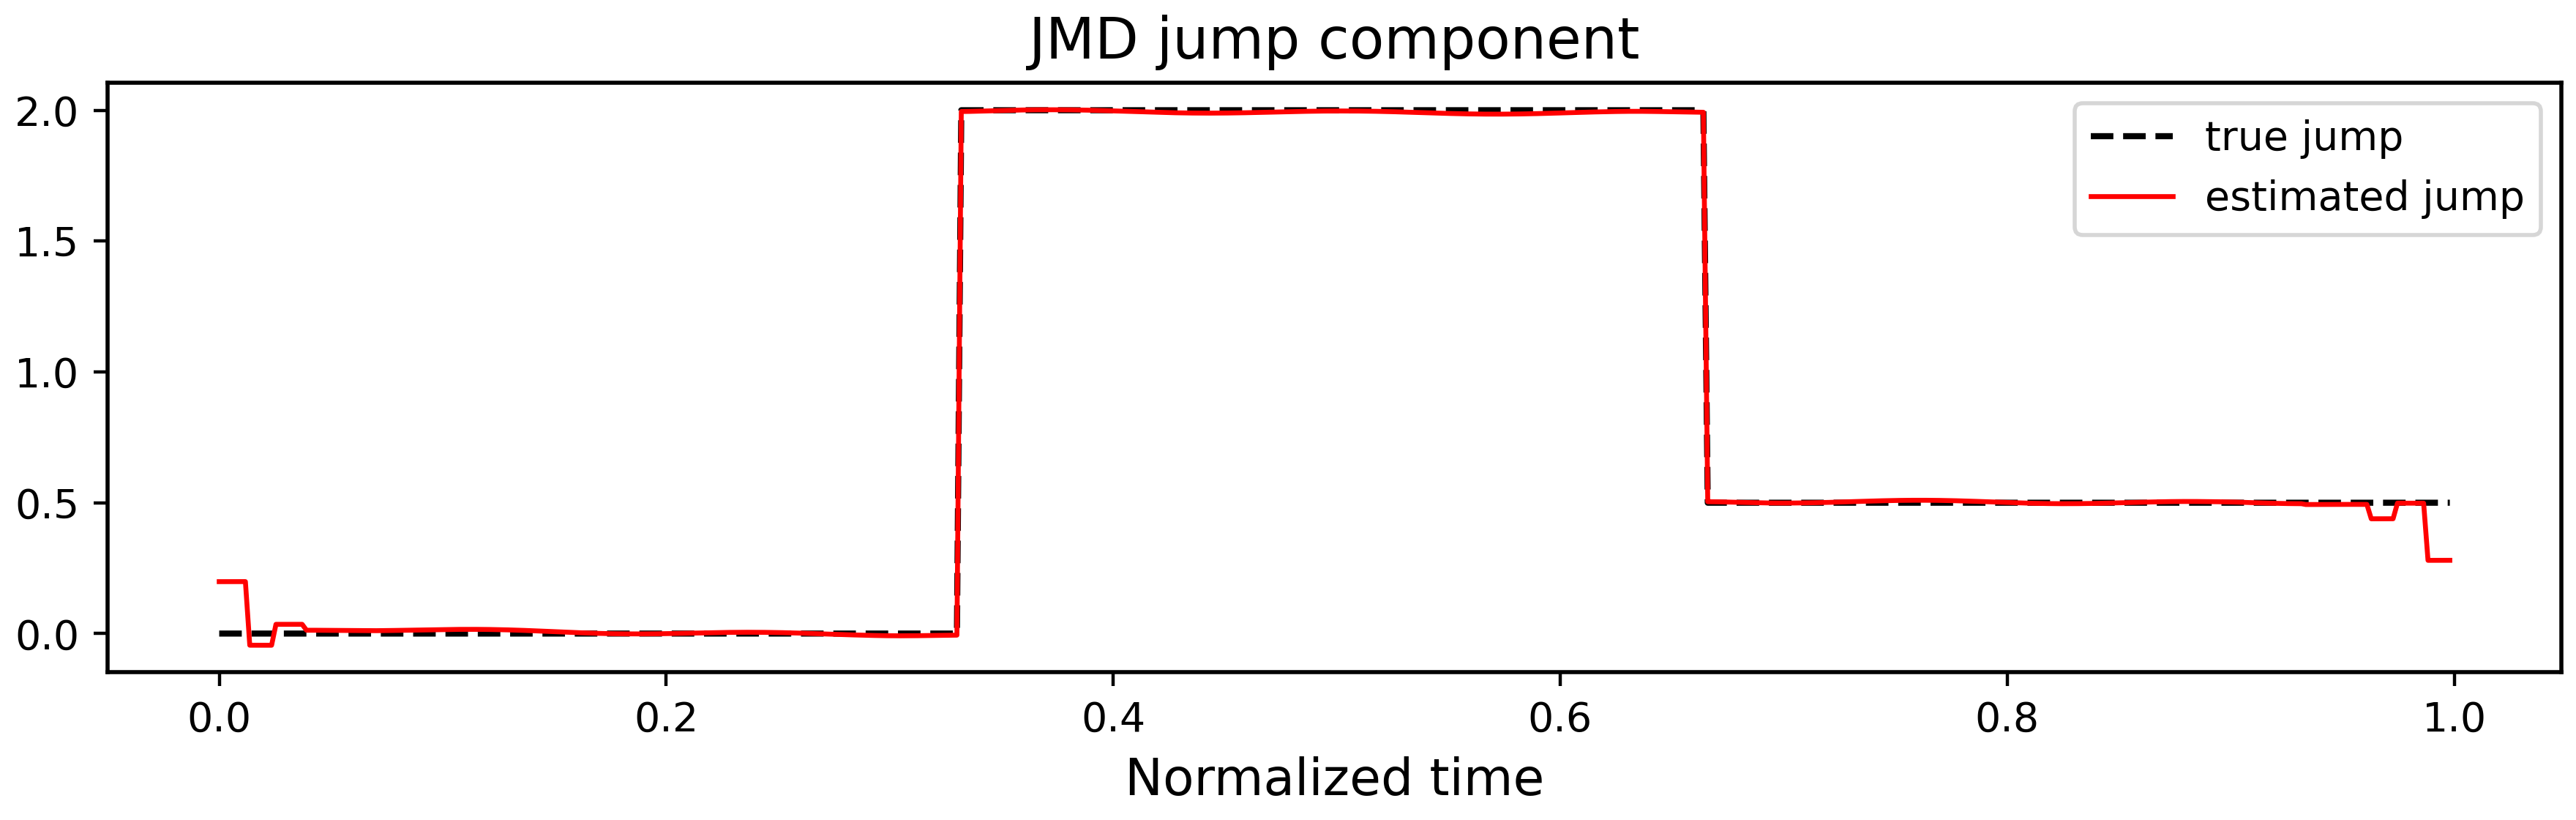

In [2]:
def make_jmd_demo(n: int = 512, seed: int = 0):
    rng = np.random.default_rng(seed)
    t = np.arange(n, dtype=float) / n
    s1 = 2.0 * np.cos(2 * np.pi * 8 * t)
    s2 = 1.5 * np.cos(2 * np.pi * 40 * t)
    jump = np.zeros(n)
    jump[n // 3 :] += 2.0
    jump[2 * n // 3 :] -= 1.5
    signal = s1 + s2 + jump + 0.05 * rng.standard_normal(n)
    return t, signal, s1, s2, jump


t, signal, s1, s2, jump_true = make_jmd_demo()
fig = plot_signal(t, signal)
fig.suptitle("JMD input: tones + jump", fontsize=12)
plt.tight_layout()
plt.show()

jmd = JMD(K=2, alpha=5000, tau=5, beta=0.03, b_bar=0.45, tol=1e-5, max_iter=400)
u, v, omega = jmd.fit_transform(signal, return_all=True)

print("modes:", u.shape, "jump:", v.shape)
print("center frequencies (normalized):", omega)
print("Hz (if fs=N):", omega * len(t))
print(
    "reconstruction RE:",
    np.linalg.norm(u.sum(0) + v - signal) / np.linalg.norm(signal),
)

plot_IMFs(signal, u)
plt.suptitle("JMD oscillatory modes", fontsize=12)
plt.show()

fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(t, jump_true, "k--", lw=1.5, label="true jump")
ax.plot(t, v, "r-", lw=1.2, label="estimated jump")
ax.set_xlabel("Normalized time")
ax.set_title("JMD jump component")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Multivariate demo (MJMD)

Three channels sharing oscillatory frequencies, plus a common-time jump pattern (inspired by `MJMD_test.m`).

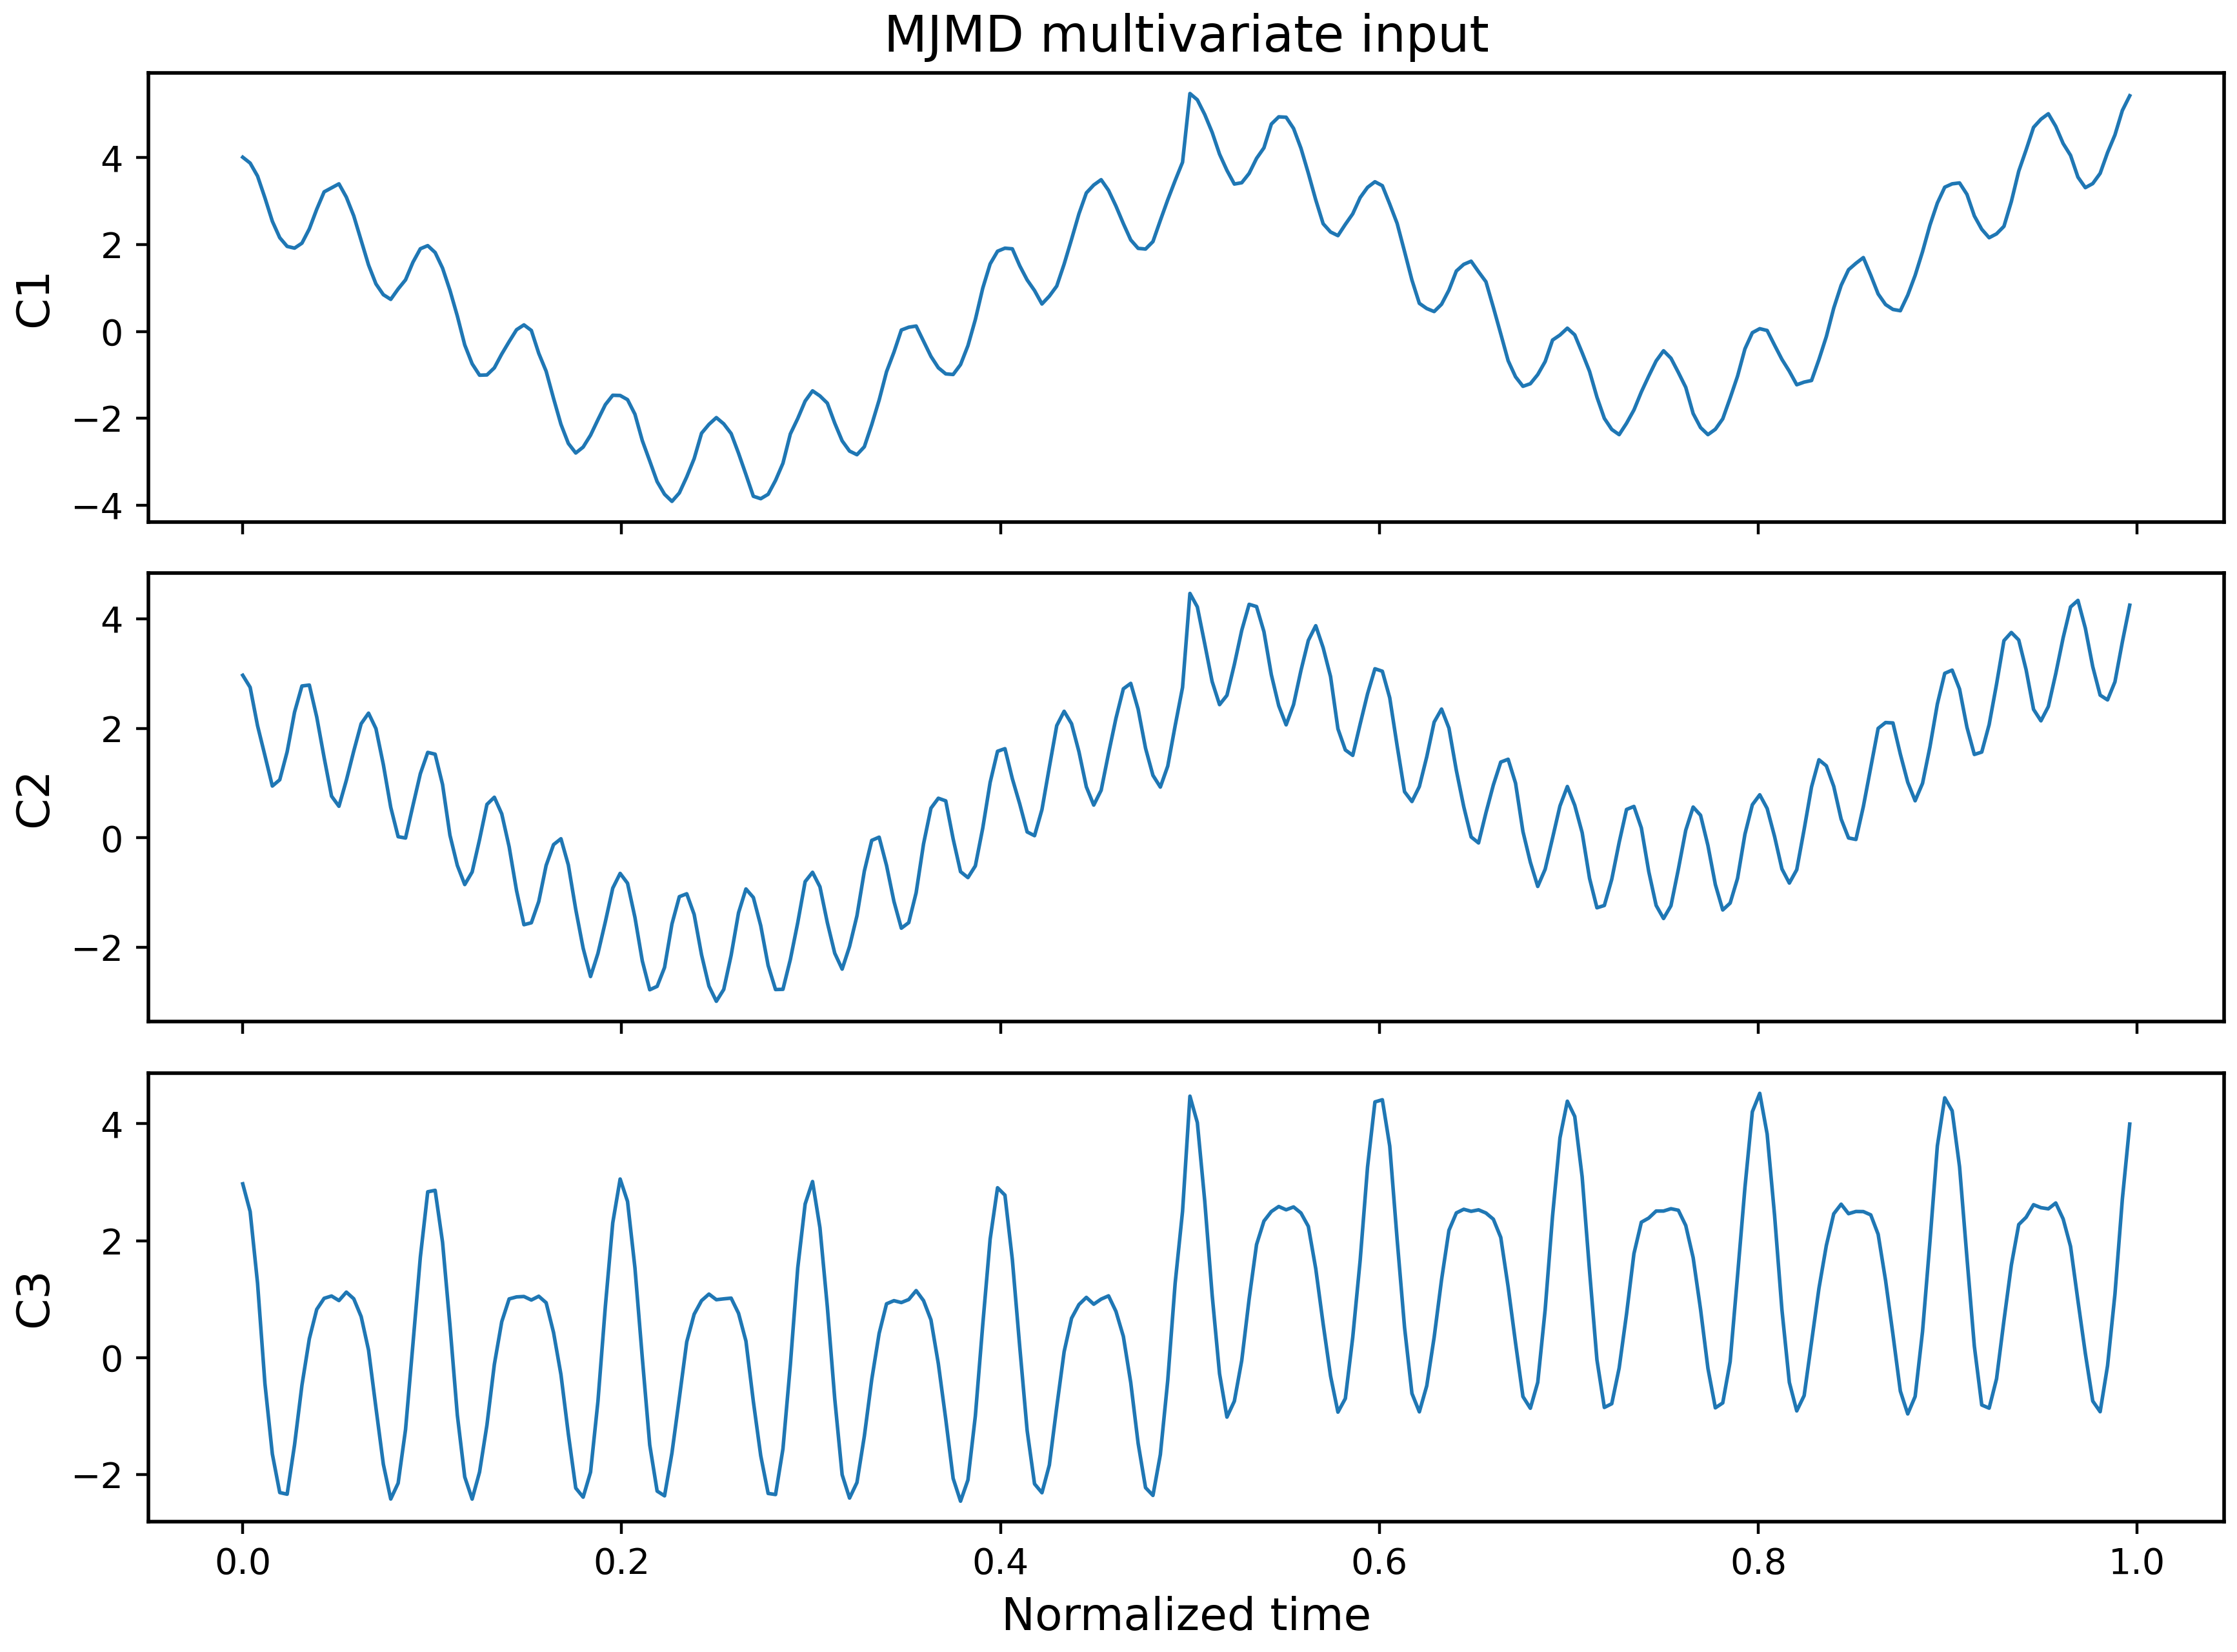

modes (K, N, C): (2, 256, 3)
jump (C, N): (3, 256)
shared omega (normalized): [0.0078 0.0782]
reconstruction RE: 0.08666422337613193


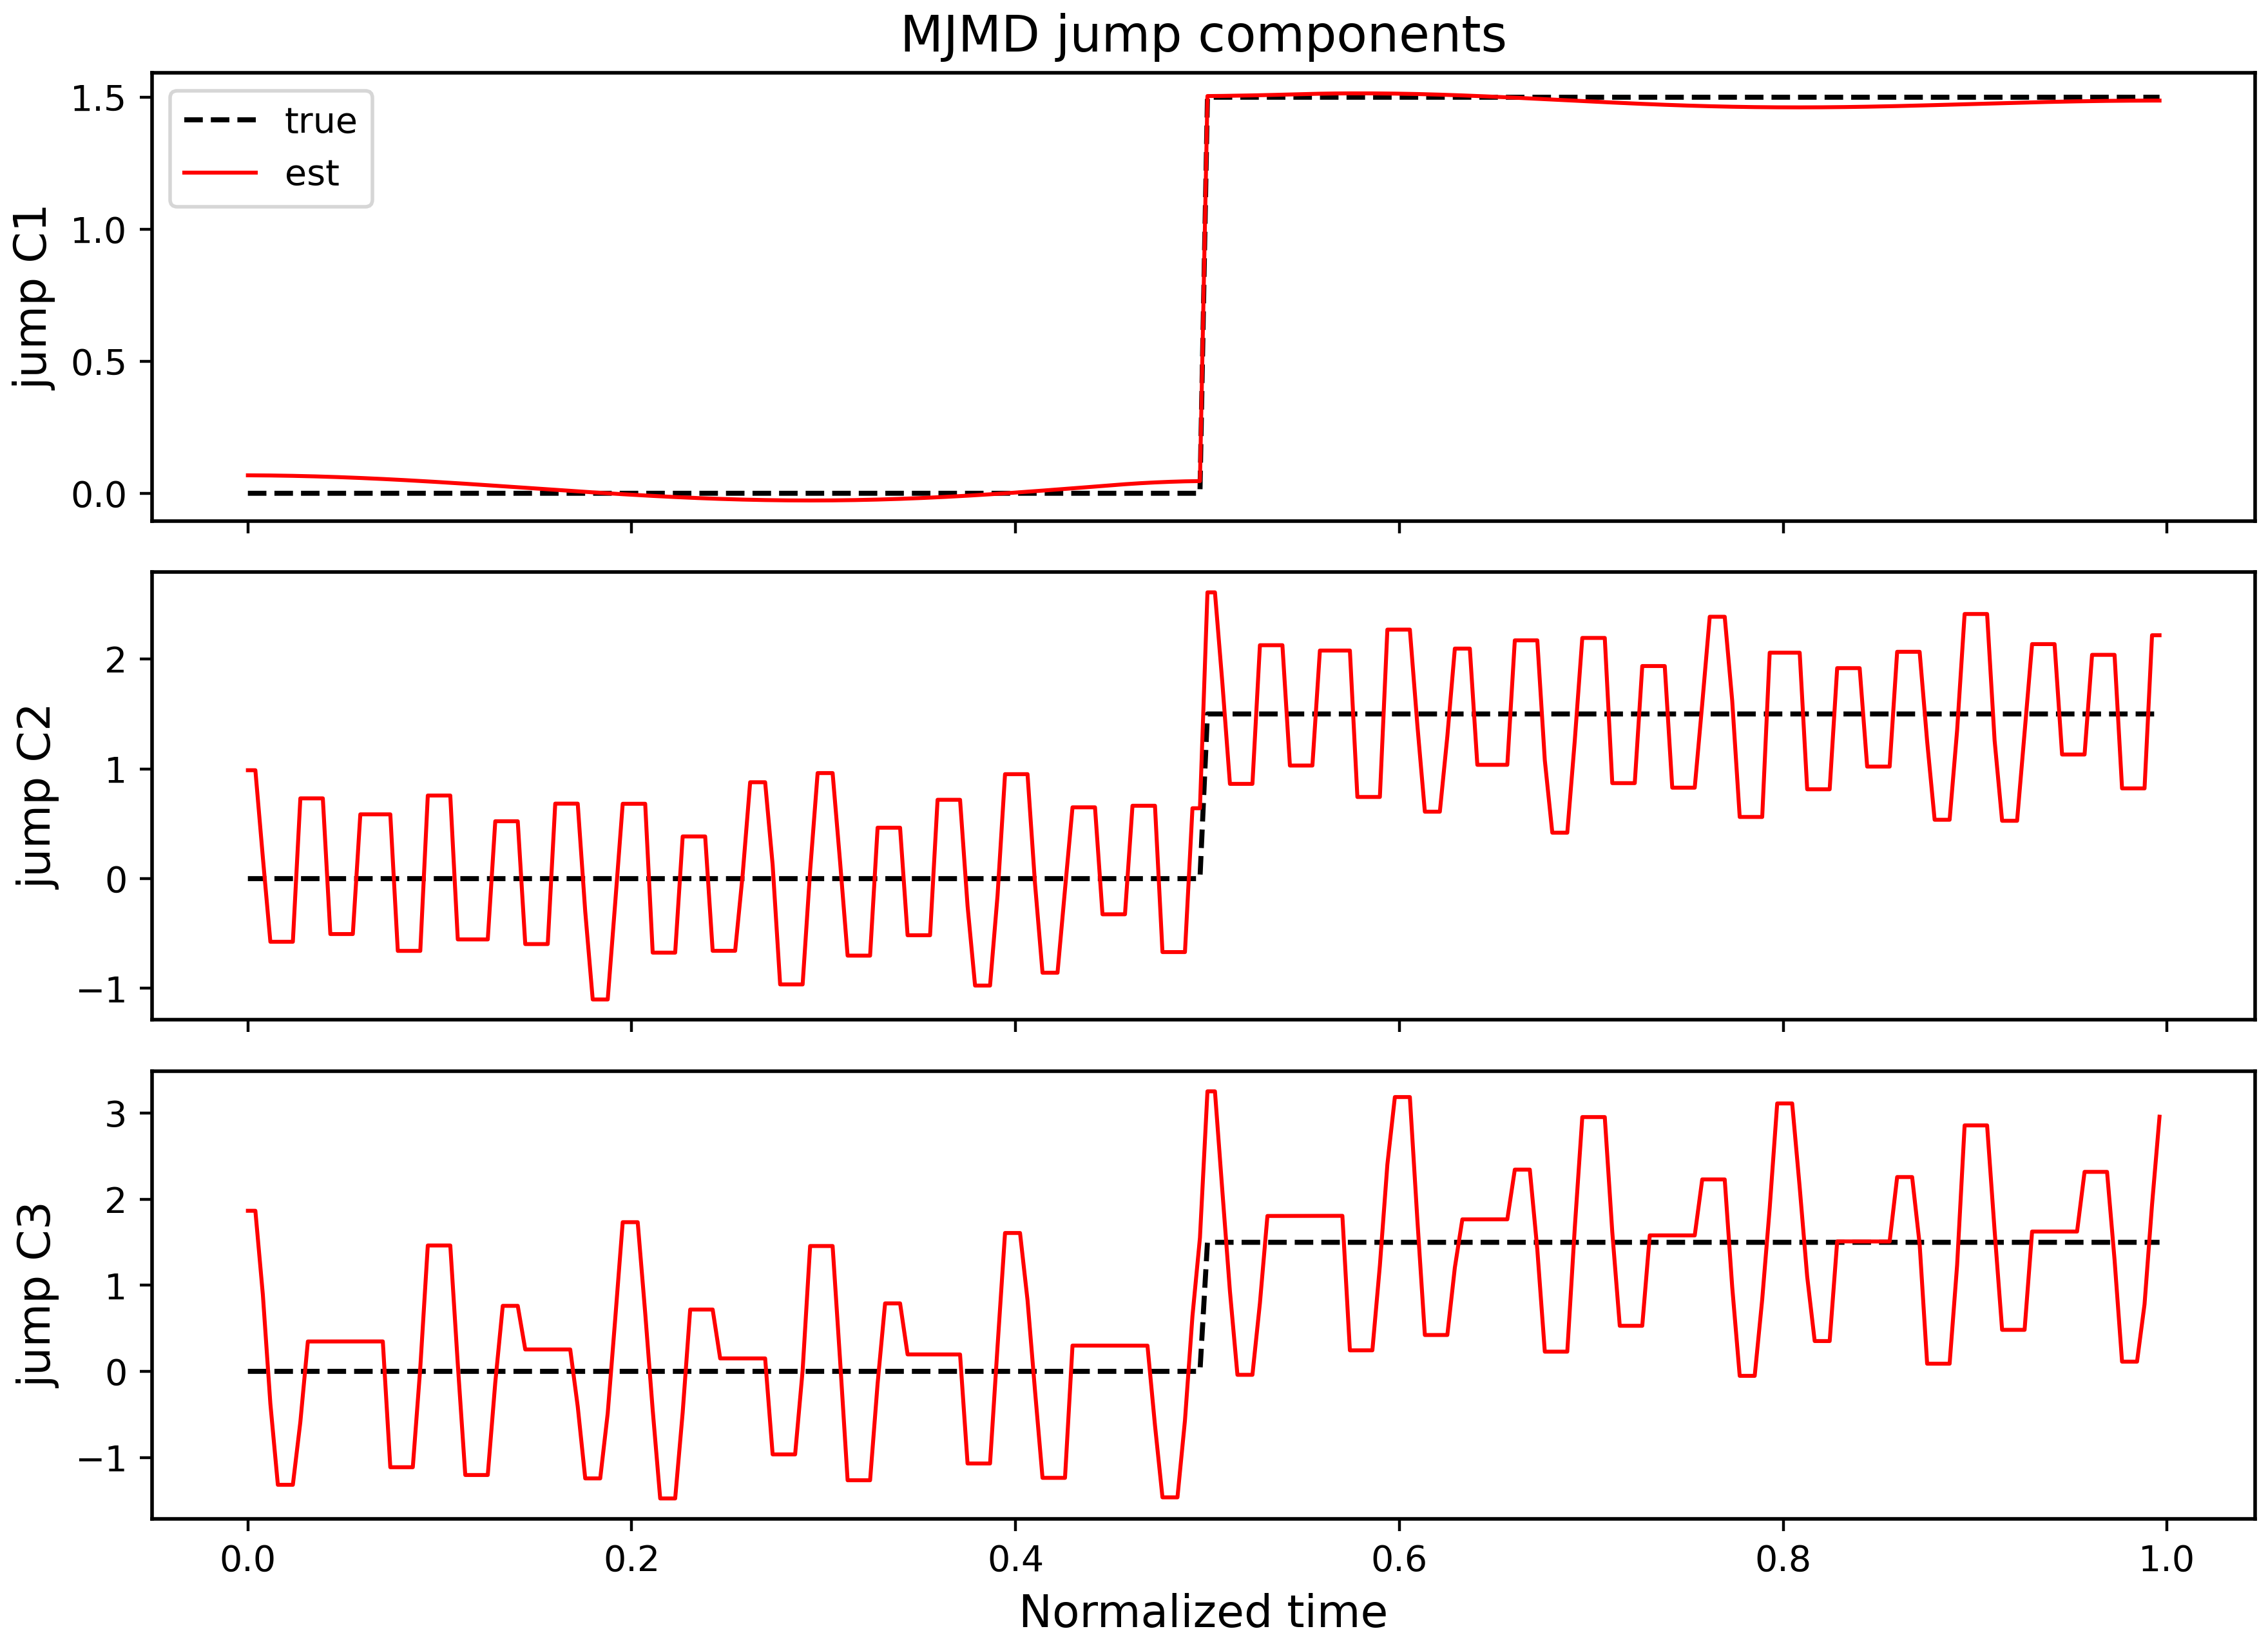

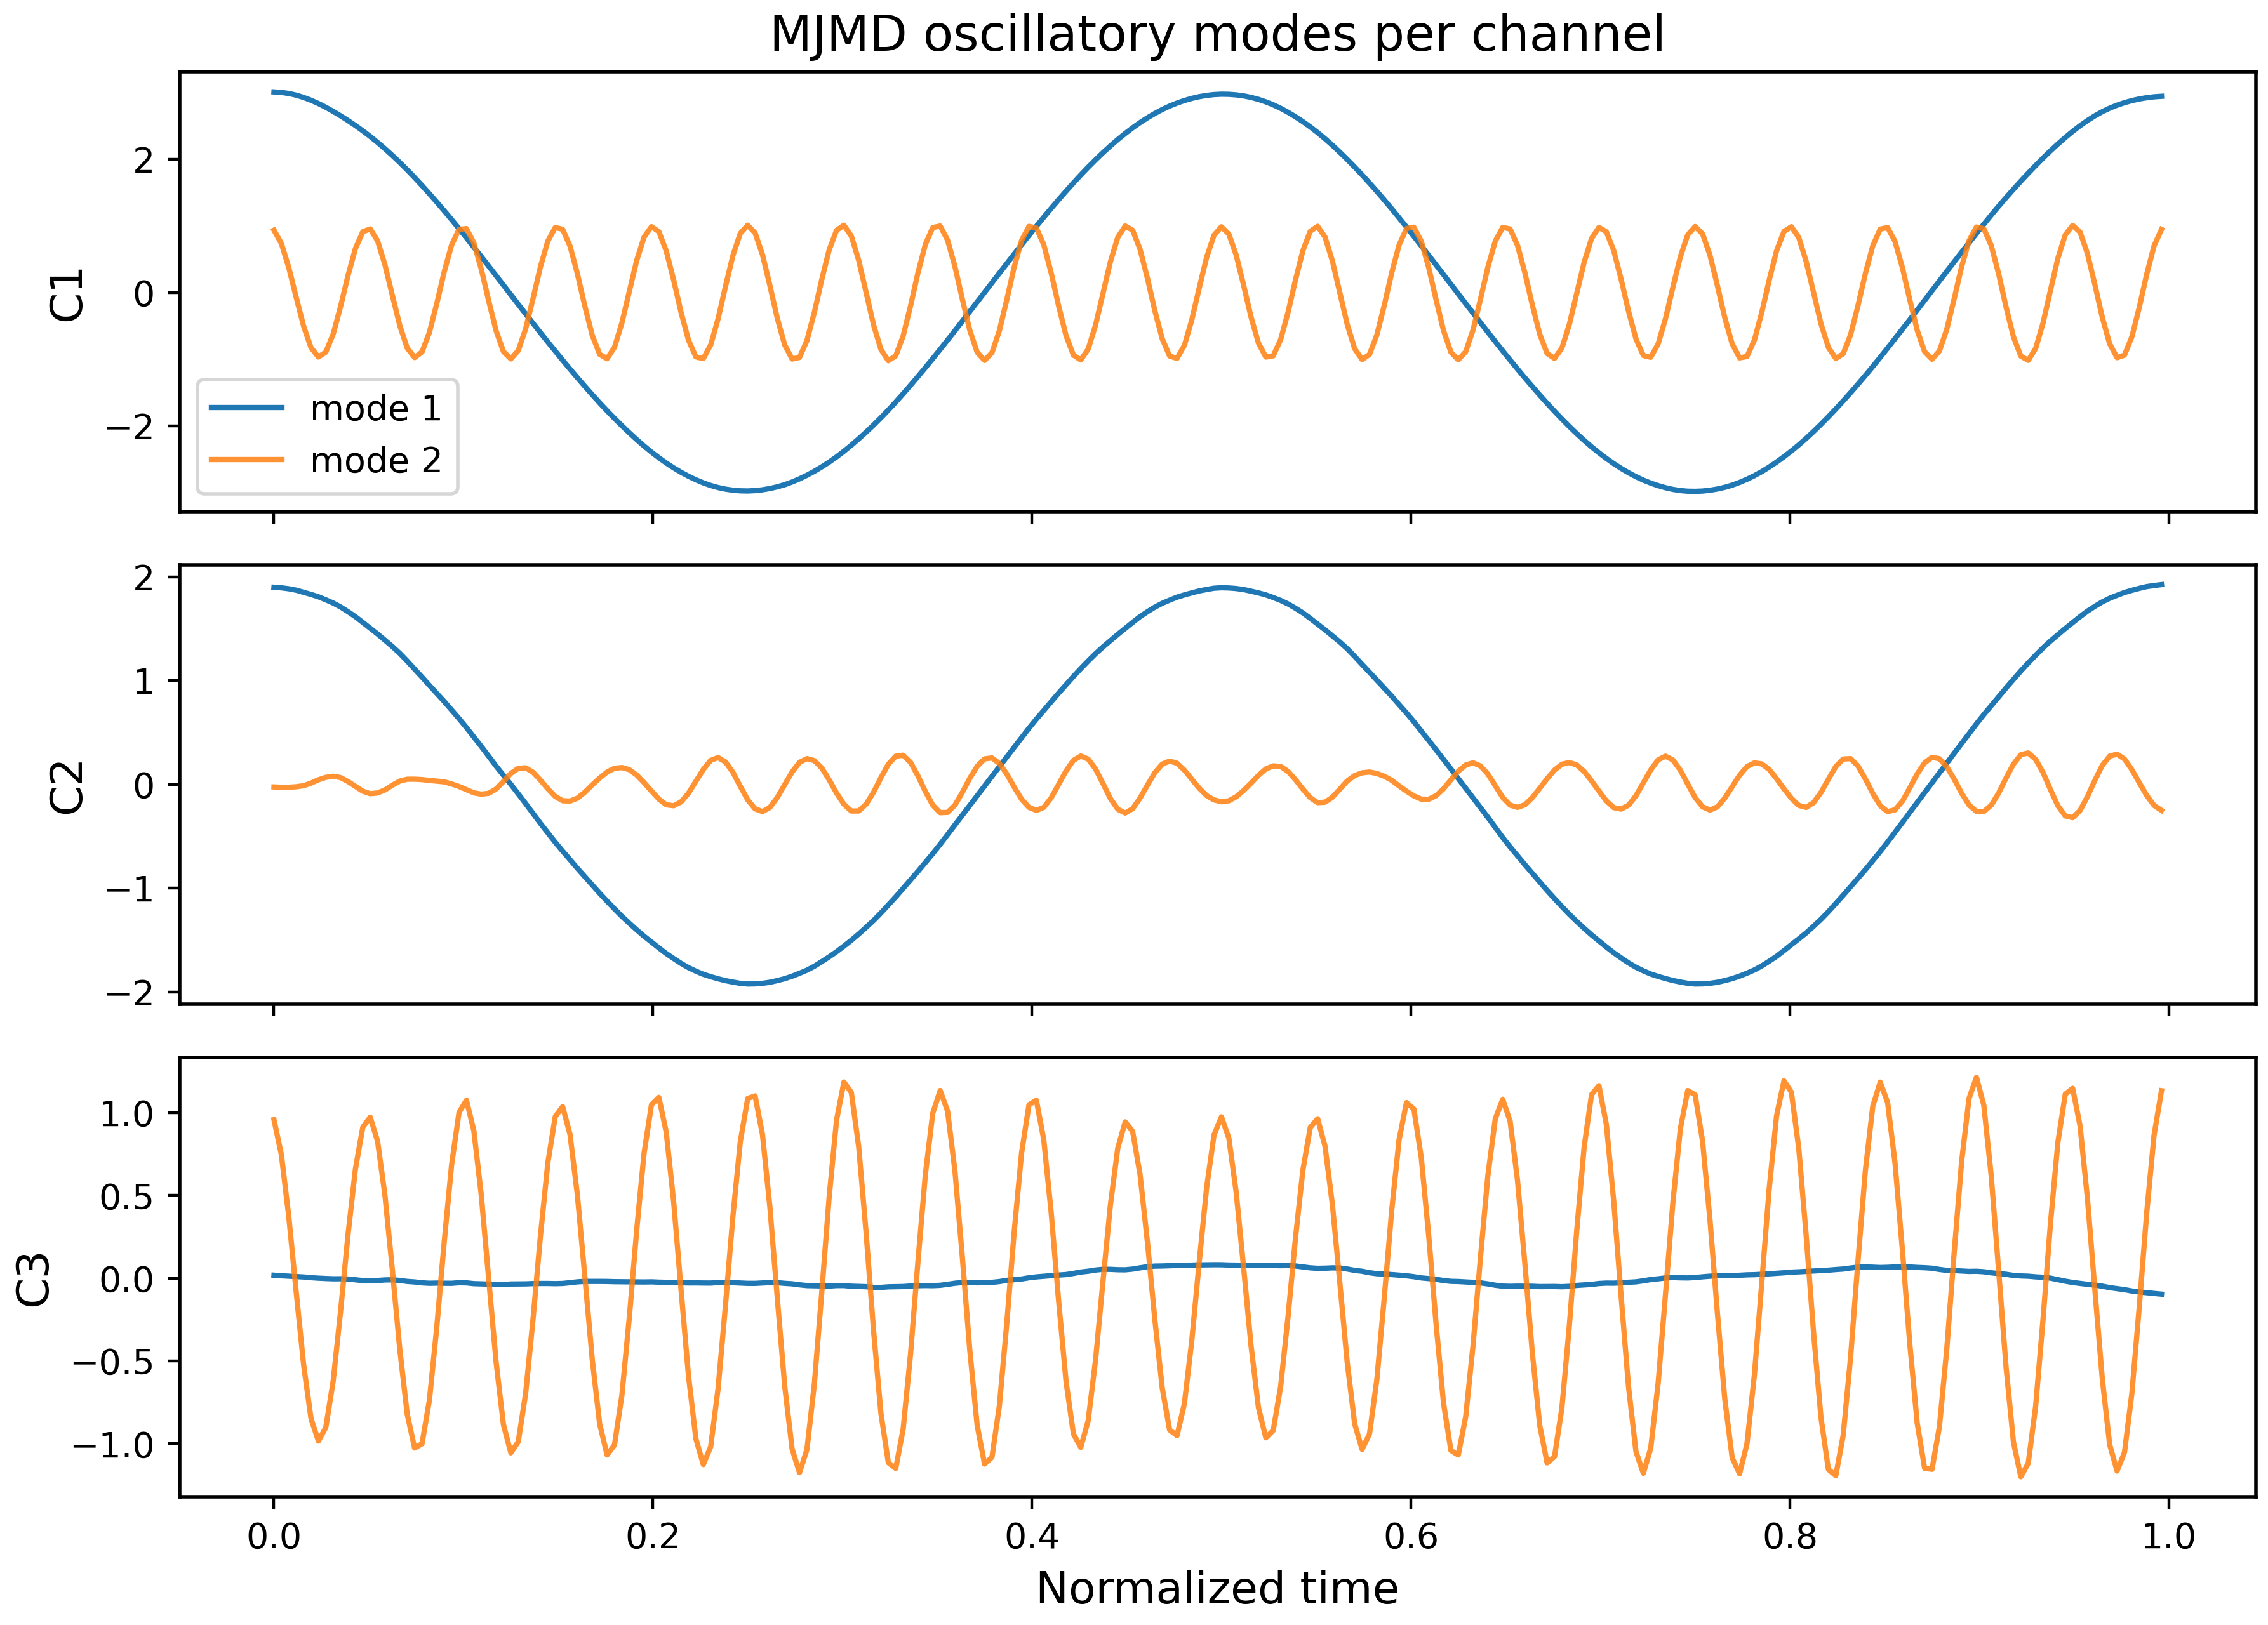

In [3]:
def make_mjmd_demo(n: int = 256, seed: int = 0):
    rng = np.random.default_rng(seed)
    t = np.arange(n, dtype=float) / n
    x = np.vstack(
        [
            3.0 * np.cos(2 * np.pi * 2 * t) + np.cos(2 * np.pi * 20 * t),
            2.0 * np.cos(2 * np.pi * 2 * t) + np.cos(2 * np.pi * 30 * t),
            2.0 * np.cos(2 * np.pi * 20 * t) + np.cos(2 * np.pi * 30 * t),
        ]
    )
    jump = np.zeros_like(x)
    jump[:, n // 2 :] += 1.5
    signal = x + jump + 0.05 * rng.standard_normal(x.shape)
    return t, signal, x, jump


t_m, Sig, X_true, jump_m = make_mjmd_demo()
C = Sig.shape[0]

fig, axes = plt.subplots(C, 1, figsize=(9, 2.2 * C), sharex=True)
for c, ax in enumerate(axes):
    ax.plot(t_m, Sig[c], lw=1.0)
    ax.set_ylabel(f"C{c+1}")
axes[0].set_title("MJMD multivariate input")
axes[-1].set_xlabel("Normalized time")
plt.tight_layout()
plt.show()

mjmd = MJMD(K=2, alpha=3000, tau=5, beta=0.05, b_bar=0.45, tol=1e-4, max_iter=250)
U, J, om = mjmd.fit_transform(Sig, return_all=True)
print("modes (K, N, C):", U.shape)
print("jump (C, N):", J.shape)
print("shared omega (normalized):", om)
print(
    "reconstruction RE:",
    np.linalg.norm(U.sum(0).T + J - Sig) / np.linalg.norm(Sig),
)

fig, axes = plt.subplots(C, 1, figsize=(9, 2.2 * C), sharex=True)
for c, ax in enumerate(axes):
    ax.plot(t_m, jump_m[c], "k--", lw=1.4, label="true")
    ax.plot(t_m, J[c], "r-", lw=1.1, label="est")
    ax.set_ylabel(f"jump C{c+1}")
    if c == 0:
        ax.legend(loc="best")
        ax.set_title("MJMD jump components")
axes[-1].set_xlabel("Normalized time")
plt.tight_layout()
plt.show()

# One mode across channels
fig, axes = plt.subplots(C, 1, figsize=(9, 2.2 * C), sharex=True)
for c, ax in enumerate(axes):
    ax.plot(t_m, U[0, :, c], label="mode 1")
    ax.plot(t_m, U[1, :, c], label="mode 2", alpha=0.85)
    ax.set_ylabel(f"C{c+1}")
    if c == 0:
        ax.legend(loc="best")
        ax.set_title("MJMD oscillatory modes per channel")
axes[-1].set_xlabel("Normalized time")
plt.tight_layout()
plt.show()

## 5. Takeaways

- **JMD**: univariate AM–FM modes + one jump component.
- **MJMD**: multichannel modes with shared $\omega_k$ + per-channel jumps.
- Key parameters: `alpha` (oscillation bandwidth), `beta` / `b_bar` / `tau` (jump prior), `K`.
- PySDKit API:
  - `from pysdkit import JMD, MJMD`
  - `u, v, omega = JMD(K=...).fit_transform(x, return_all=True)`
  - `U, J, omega = MJMD(K=...).fit_transform(X, return_all=True)` with `X` shape `(C, N)`

**Further reading**

- Nazari et al., arXiv:2407.07800 (JMD / MJMD).
- Dragomiretskiy & Zosso, VMD (IEEE TSP 2014); Rehman & Aftab, MVMD (IEEE TSP 2019).
- Huska et al., JOT (IPOL 2023).